    year interval_start interval_end  N_total  N_HD  HD_frequency_interval  \
0   2012     2011-10-13   2012-10-24       25     5               0.200000   
1   2013     2012-10-24   2013-11-09       22     6               0.272727   
2   2014     2013-11-09   2014-10-05       23     2               0.086957   
3   2015     2014-10-05   2015-09-21       20     0               0.000000   
4   2016     2015-09-21   2016-09-20       27     5               0.185185   
5   2017     2016-09-20   2017-10-10       20     0               0.000000   
6   2018     2017-10-10   2018-10-20       24     4               0.166667   
7   2019     2018-10-20   2019-10-04       16     0               0.000000   
8   2020     2019-10-04   2020-09-21       24     1               0.041667   
9   2021     2020-09-21   2021-09-28       25     9               0.360000   
10  2022     2021-09-28   2022-09-29       21     1               0.047619   
11  2023     2022-09-29   2023-09-24       21     0             

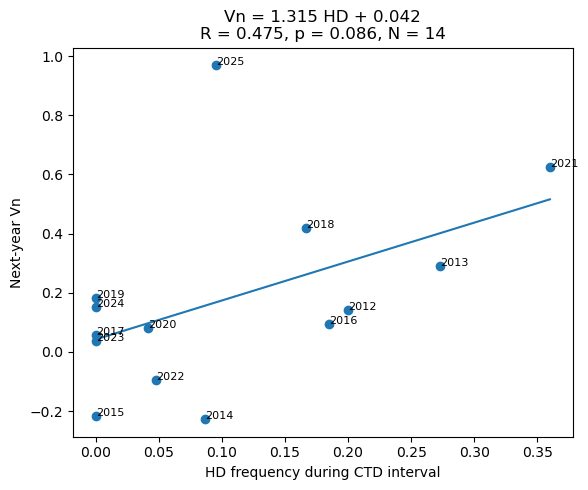

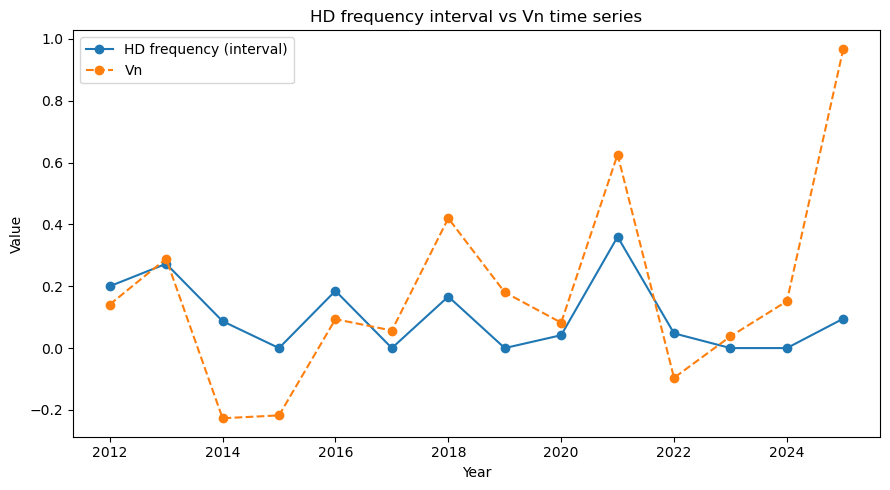

In [1]:
import pandas as pd
import numpy as np
import gsw
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import linregress

# =========================================================
# 1. Read Sognesjøen 75 m data and compute sigma0
# =========================================================
sogne_file = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\Sognesjoen.txt"

df_s = pd.read_csv(
    sogne_file,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=[
        "station",
        "date",
        "clock",
        "depth",
        "temp",
        "salt",
        "temp_cal",
        "salt_cal"
    ]
)

# Combine date and time
df_s["time"] = pd.to_datetime(
    df_s["date"] + " " + df_s["clock"],
    dayfirst=True
)

# Keep only 75 m observations
df_s = df_s[df_s["depth"] == 75].copy()

# Use calibrated temperature and salinity
T = df_s["temp_cal"].astype(float).values
S = df_s["salt_cal"].astype(float).values

# Sognesjøen station location
lat = 61.0233
lon = 4.84
p = gsw.p_from_z(-75, lat)

# Compute sigma0
SA = gsw.SA_from_SP(S, p, lon, lat)
CT = gsw.CT_from_t(SA, T, p)
df_s["sigma0"] = gsw.sigma0(SA, CT)

# High-density (HD) definition
HD_threshold = 27.17
df_s["HD_flag"] = df_s["sigma0"] >= HD_threshold

# =========================================================
# 2. Manually define Masfjorden CTD sampling dates
#    Interval HD frequency corresponds to next-year Vn
# =========================================================
ctd_dates = {
    2011: "2011-10-13",
    2012: "2012-10-24",
    2013: "2013-11-09",
    2014: "2014-10-05",
    2015: "2015-09-21",
    2016: "2016-09-20",
    2017: "2017-10-10",
    2018: "2018-10-20",   
    2019: "2019-10-04",   
    2020: "2020-09-21",   
    2021: "2021-09-28", 
    2022: "2022-09-29", 
    2023: "2023-09-24", 
    2024: "2024-10-08", 
    2025: "2025-10-08",
    2026: "2026-02-04",
}

ctd_df = pd.DataFrame({
    "year": list(ctd_dates.keys()),
    "ctd_time": pd.to_datetime(list(ctd_dates.values()))
}).sort_values("year").reset_index(drop=True)

# =========================================================
# 3. Compute HD frequency between consecutive CTDs
#    Each interval is assigned to the later year
# =========================================================
interval_results = []

for i in range(1, len(ctd_df)):
    start_year = int(ctd_df.loc[i - 1, "year"])
    end_year   = int(ctd_df.loc[i, "year"])
    start_time = ctd_df.loc[i - 1, "ctd_time"]
    end_time   = ctd_df.loc[i, "ctd_time"]

    # Interval definition: start_time < time <= end_time
    sub = df_s[(df_s["time"] > start_time) & (df_s["time"] <= end_time)].copy()

    n_total = len(sub)
    n_hd = int(sub["HD_flag"].sum()) if n_total > 0 else np.nan
    hd_freq = sub["HD_flag"].mean() if n_total > 0 else np.nan

    interval_results.append({
        "year": end_year,
        "interval_start": start_time,
        "interval_end": end_time,
        "N_total": n_total,
        "N_HD": n_hd,
        "HD_frequency_interval": hd_freq
    })

hd_interval_df = pd.DataFrame(interval_results)

# =========================================================
# 4. Load Vn time series
# =========================================================
vn_file = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\Vn_timeseries_2011_2026.csv"

vn_df = pd.read_csv(vn_file)

# Keep only relevant columns
vn_df = vn_df[["year", "O2_200_400m_mLL", "Vn"]].copy()
vn_df["year"] = vn_df["year"].astype(int)

# =========================================================
# 5. Merge HD frequency interval with next-year Vn
# =========================================================
compare_df = pd.merge(hd_interval_df, vn_df, on="year", how="left")

# Remove 2026
compare_df = compare_df[compare_df["year"] != 2026].copy()

# Save results
out_file = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\HD_interval_vs_Vn.csv"
compare_df.to_csv(out_file, index=False)

print(compare_df)
print("Saved:", out_file)

# =========================================================
# 6. Correlation and linear regression
# =========================================================
valid = compare_df.dropna(subset=["HD_frequency_interval", "Vn"]).copy()

# Pearson correlation
r, p_corr = pearsonr(
    valid["HD_frequency_interval"],
    valid["Vn"]
)

# Linear regression
reg = linregress(
    valid["HD_frequency_interval"],
    valid["Vn"]
)

slope = reg.slope
intercept = reg.intercept
r_reg = reg.rvalue
p_reg = reg.pvalue
stderr = reg.stderr

print("Linear relationship:")
print(f"Vn = {slope:.4f} * HD + {intercept:.4f}")
print(f"R = {r_reg:.4f}")
print(f"p = {p_reg:.4f}")
print(f"N = {len(valid)}")

# =========================================================
# 7. Scatter plot with regression line
# =========================================================
plt.figure(figsize=(6,5))

x = valid["HD_frequency_interval"]
y = valid["Vn"]

plt.scatter(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line)

for _, row in valid.iterrows():
    plt.text(row["HD_frequency_interval"], row["Vn"], str(int(row["year"])), fontsize=8)

plt.xlabel("HD frequency during CTD interval")
plt.ylabel("Next-year Vn")

plt.title(
    f"Vn = {slope:.3f} HD + {intercept:.3f}\n"
    f"R = {r_reg:.3f}, p = {p_reg:.3f}, N = {len(valid)}"
)

plt.tight_layout()
plt.show()

# =========================================================
# 8. Plot both time series
# =========================================================
plt.figure(figsize=(9, 5))

plt.plot(
    valid["year"],
    valid["HD_frequency_interval"],
    marker="o",
    linestyle="-",
    label="HD frequency (interval)"
)

plt.plot(
    valid["year"],
    valid["Vn"],
    marker="o",
    linestyle="--",
    label="Vn"
)

plt.xlabel("Year")
plt.ylabel("Value")

plt.title("HD frequency interval vs Vn time series")

plt.legend()
plt.tight_layout()
plt.show()